# City Profiles Clustering - Plotting Notebook

This notebook creates clean, publication-ready visualizations for city mobility profiles.
- **Data source**: City profiles with clustering information
- **Main visualizations**: Scatter plots showing relationships between urban metrics
- **Output**: High-quality figures saved as PDF and SVG

## 1. Import Libraries and Configure Plot Settings

In [1]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator
import pickle

# For advanced text positioning in plots
from adjustText import adjust_text

# Optional: for geographic visualizations
import geopandas as gpd
from scipy import stats

# Display inline plots in Jupyter
%matplotlib inline

print('✓ All libraries loaded successfully!')

✓ All libraries loaded successfully!


In [2]:
# Configure matplotlib for publication-quality plots
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'serif'

# Font and line settings for better visibility
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 1.5

print('✓ Plot settings configured')

✓ Plot settings configured


## 2. Define Color and Marker Schemes

Consistent color palettes for gender, socioeconomic class, and cluster categories.

In [3]:
# Color scheme for demographic categories
colors = {
    # Gender-based colors
    'Men': '#009E73',
    'Women': '#E69F00',
    'Men Married': '#0072B2',
    'Women Married': '#D55E00',
    'All': 'black',
    
    # Socioeconomic class colors
    'Upper class': '#0072B2',
    'Middle class': '#009E73',
    'Lower class': '#D55E00',
    
    # Cluster colors (colorblind-friendly)
    'C1': '#56B4E9',  # Cluster 1: Light blue
    'C2': '#CC79A7',  # Cluster 2: Purple
    
    # Special colors
    'lightgrey': 'lightgrey'
}

# Marker scheme for cluster identification
markers = {
    'C1': 'P',  # Pentagon marker for Cluster 1
    'C2': 'X',  # X marker for Cluster 2
    'o': 'o',   # Circle for other categories
}

print('✓ Color and marker schemes defined')

✓ Color and marker schemes defined


## 3. Load Data

In [4]:
# Load city profiles data from CSV
# This dataset contains clustering assignments and urban metrics
data_path = 'datasets/organised_cities_groups_2.csv'
cities_data = pd.read_csv(data_path)

# Display basic information
print(f'✓ Data loaded: {len(cities_data)} cities')
print(f'  Columns: {list(cities_data.columns)}')
print(f'  Years: {sorted(cities_data["year"].unique())}')
print(f'  Clusters: {sorted(cities_data["cluster"].unique())}')

✓ Data loaded: 200 cities
  Columns: ['Unnamed: 0', 'cluster', 'city', 'year', 'hotspots_cuts_1_dest', 'flow_hierarchy_dest', 'mean_mob_div', '% of areas', 'Fraction of areas']
  Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
  Clusters: ['C1', 'C2']


In [5]:
# Filter for a specific year (example: 2018)
year_of_interest = 2018
data_filtered = cities_data[cities_data['year'] == year_of_interest].copy()

# Add visual properties based on cluster assignment
data_filtered['color'] = data_filtered['cluster'].apply(lambda x: colors.get(x, 'gray'))
data_filtered['marker'] = data_filtered['cluster'].apply(lambda x: markers.get(x, 'o'))

print(f'✓ Data filtered for year {year_of_interest}: {len(data_filtered)} cities')
print(f'\nFirst few rows:')
print(data_filtered.head())

✓ Data filtered for year 2018: 50 cities

First few rows:
     Unnamed: 0 cluster            city  year  hotspots_cuts_1_dest  \
150           0      C2     San Antonio  2018              0.954315   
151           1      C2          Austin  2018              0.958333   
152           2      C2         Houston  2018              0.909931   
153           3      C1  Corpus Christi  2018              0.914286   
154           4      C2     New Orleans  2018              0.892562   

     flow_hierarchy_dest  mean_mob_div  % of areas  Fraction of areas  \
150             0.556690      0.862269    0.045685           0.045685   
151             0.678444      0.837974    0.041667           0.041667   
152             0.669203      0.833834    0.090069           0.090069   
153             0.822232      0.880526    0.085714           0.085714   
154             0.652052      0.743010    0.107438           0.107438   

       color marker  
150  #CC79A7      X  
151  #CC79A7      X  
152  #CC79

## 4. Create Main Scatter Plot

Visualization: Flow Hierarchy vs Mobility Diversity
- X-axis: Flow Hierarchy Destination (network centrality)
- Y-axis: Mean Mobility Diversity (trip diversity)
- Colors and markers indicate cluster membership

✓ Main scatter plot created


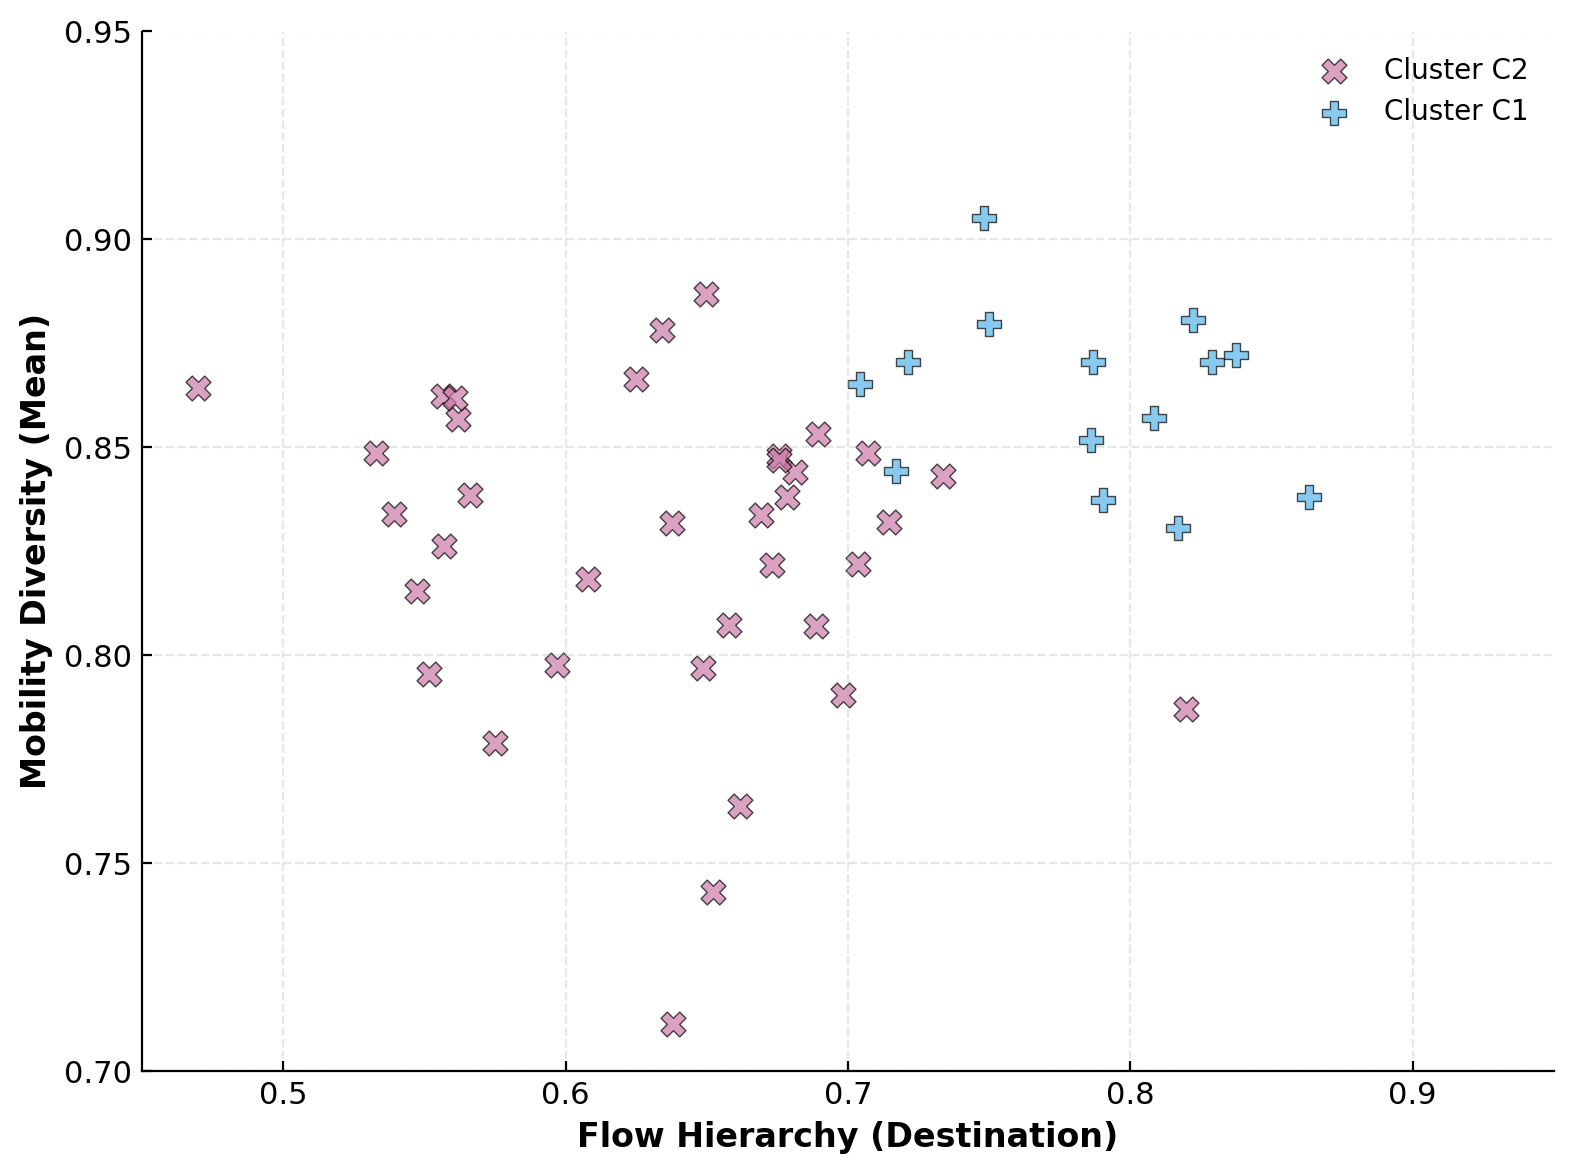

In [6]:
# Initialize figure with high DPI for quality output
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

# Plot each marker type separately to create proper legend entries
for marker in data_filtered['marker'].unique():
    # Filter data for this marker type
    subset = data_filtered[data_filtered['marker'] == marker]
    
    # Get the color for this cluster
    # (all points with same marker have same color)
    cluster_color = subset['color'].iloc[0]
    cluster_label = subset['cluster'].iloc[0]
    
    # Plot scatter points
    ax.scatter(
        subset['flow_hierarchy_dest'],
        subset['mean_mob_div'],
        color=cluster_color,
        marker=marker,
        label=f'Cluster {cluster_label}',
        s=80,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )

# Add axis labels with units/descriptions
ax.set_xlabel('Flow Hierarchy (Destination)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mobility Diversity (Mean)', fontsize=12, fontweight='bold')

# Set axis limits for better visualization
ax.set_xlim(0.45, 0.95)
ax.set_ylim(0.70, 0.95)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Add legend
ax.legend(loc='best', frameon=False, fontsize=10)

# Add grid for easier reading
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
print('✓ Main scatter plot created')
plt.show()

## 5. Scatter Plot with City Labels

Add city names as annotations with automatic text adjustment to prevent overlap.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


✓ Labeled scatter plot created


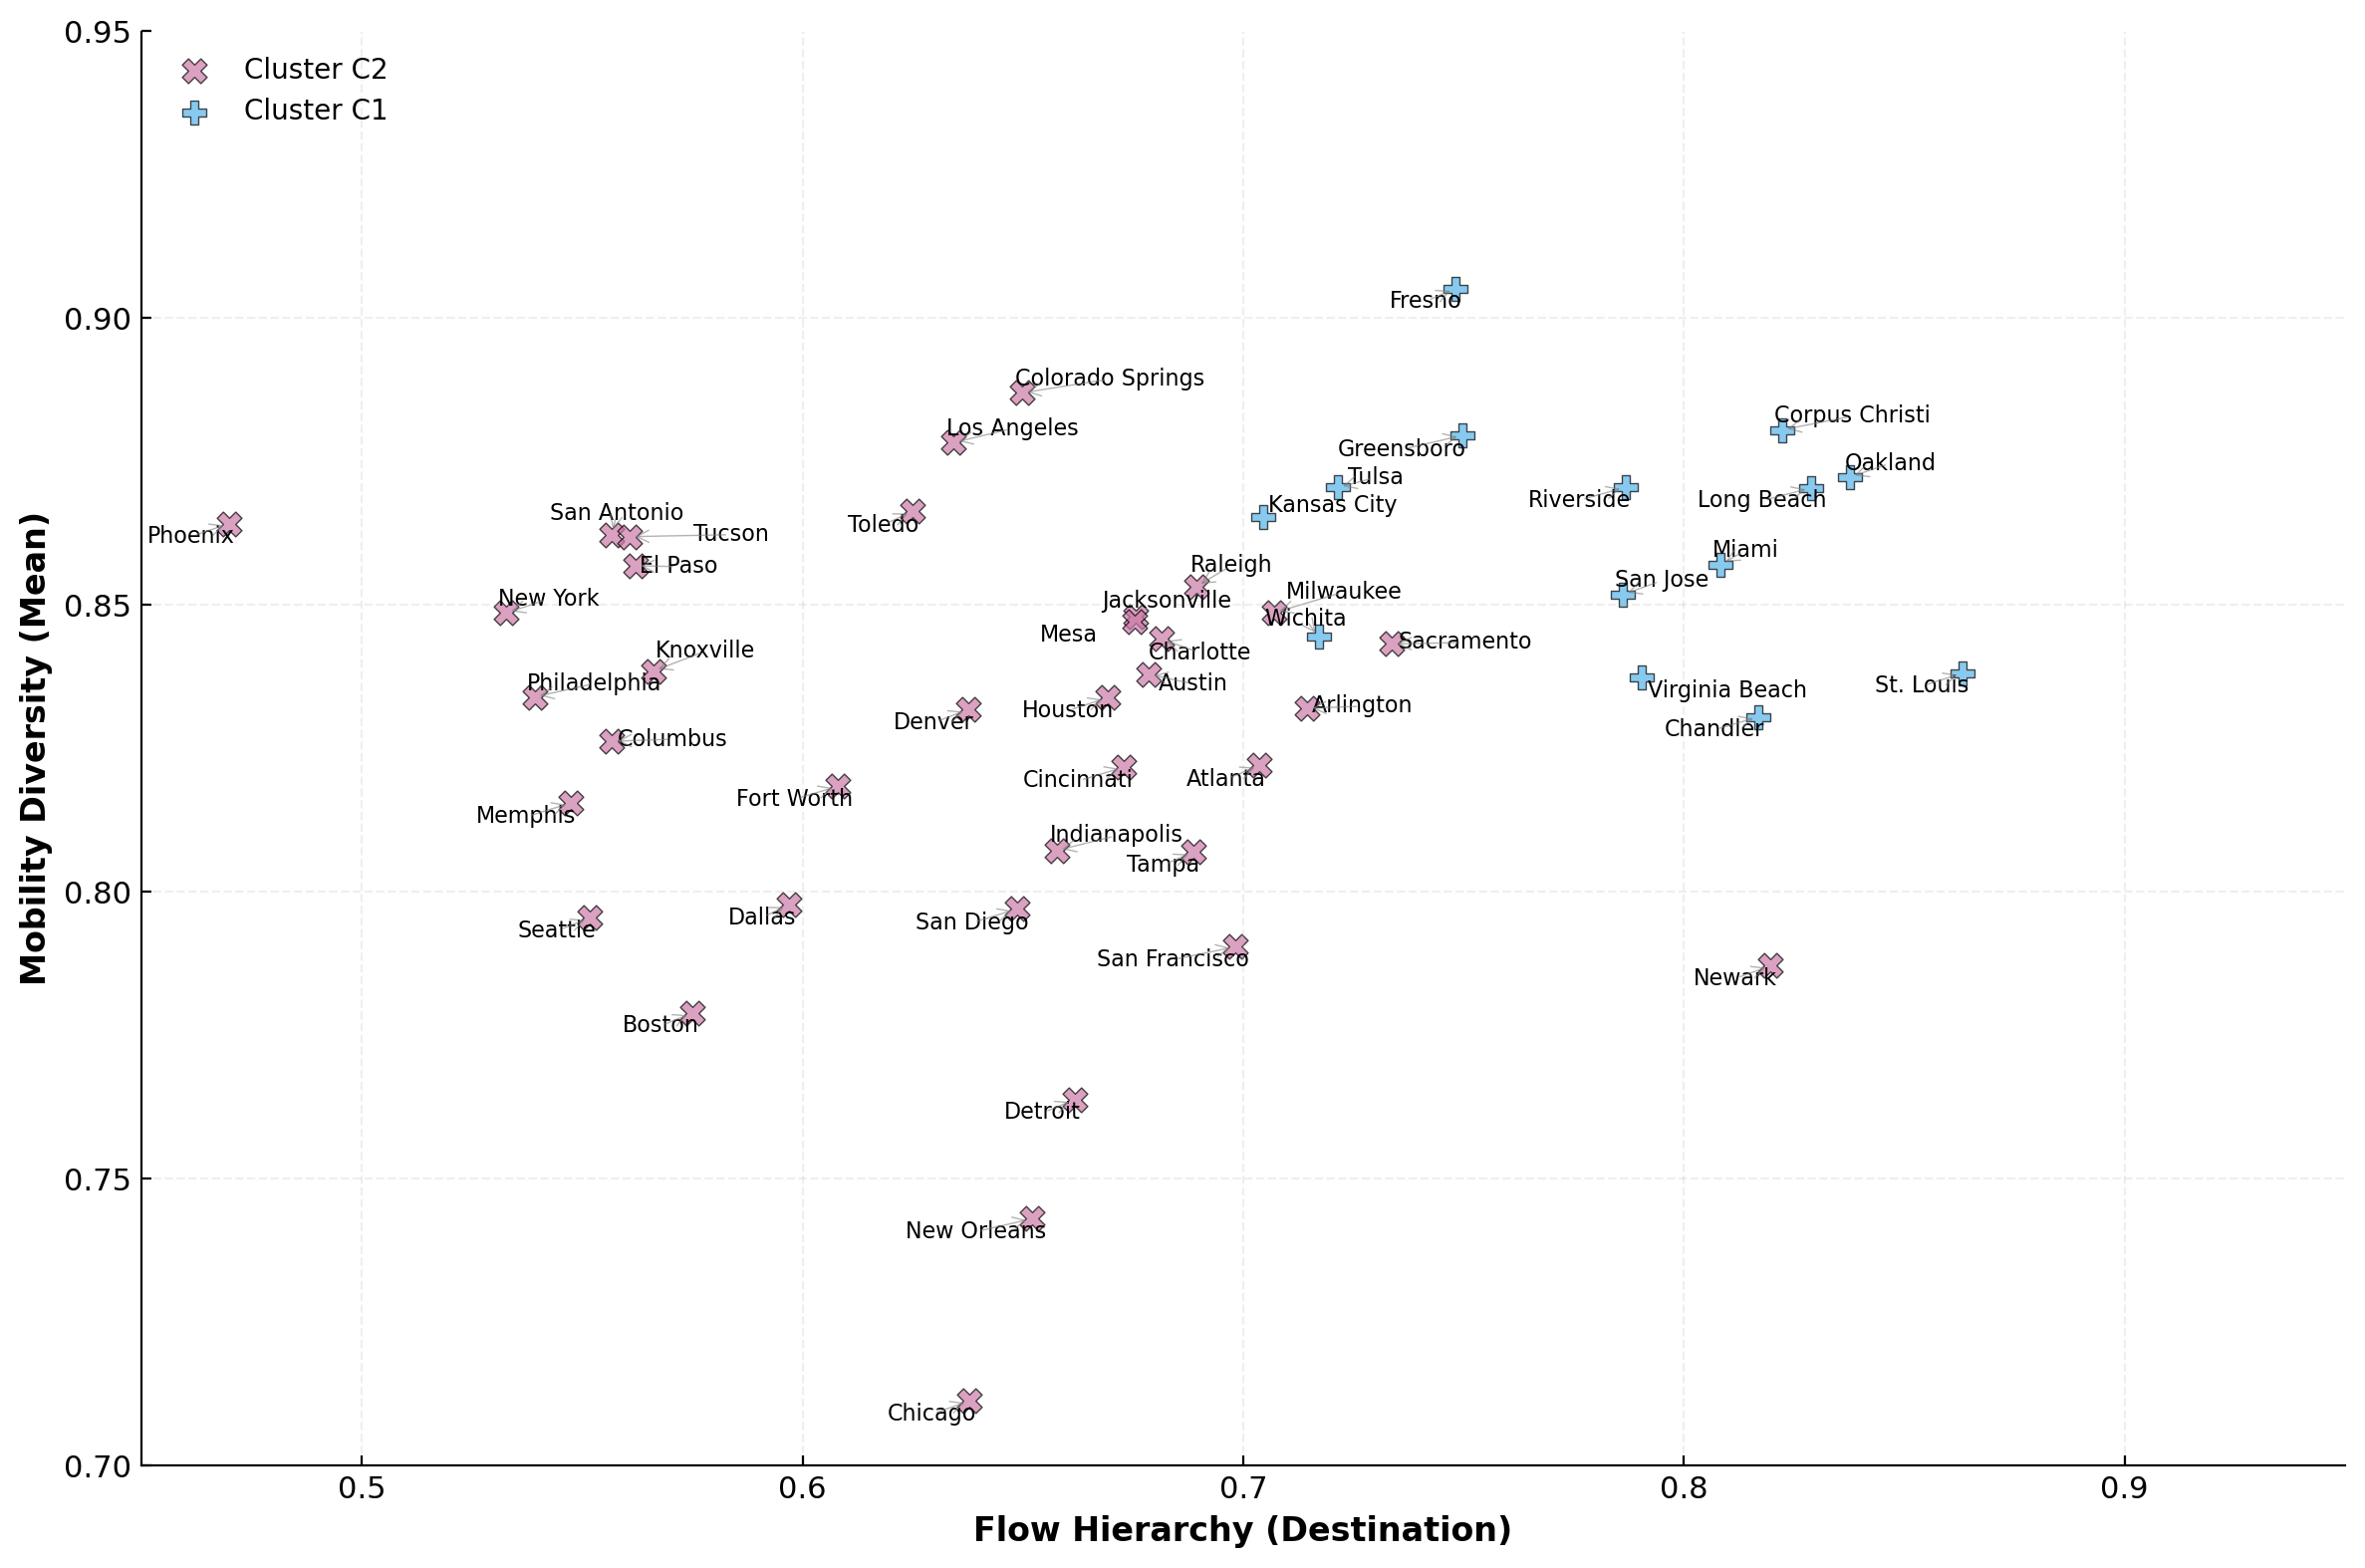

In [7]:
# Create figure with scatter plot
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

# Plot scatter points for each cluster
for marker in data_filtered['marker'].unique():
    subset = data_filtered[data_filtered['marker'] == marker]
    cluster_color = subset['color'].iloc[0]
    cluster_label = subset['cluster'].iloc[0]
    
    ax.scatter(
        subset['flow_hierarchy_dest'],
        subset['mean_mob_div'],
        color=cluster_color,
        marker=marker,
        label=f'Cluster {cluster_label}',
        s=80,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )

# Create text objects for each city (not added directly to avoid overlap)
texts = []
for idx, row in data_filtered.iterrows():
    text = ax.text(
        row['flow_hierarchy_dest'],
        row['mean_mob_div'],
        row['city'],
        fontsize=8,
        ha='center',
        va='center'
    )
    texts.append(text)

# Use adjustText to automatically reposition labels to avoid overlap
# This uses an optimization algorithm to find good label positions
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.6),
    ax=ax,
    expand_points=(1.5, 1.5)
)

# Format axes
ax.set_xlabel('Flow Hierarchy (Destination)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mobility Diversity (Mean)', fontsize=12, fontweight='bold')
ax.set_xlim(0.45, 0.95)
ax.set_ylim(0.70, 0.95)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(loc='upper left', frameon=False, fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
print('✓ Labeled scatter plot created')
plt.show()

## 6. Save Figures

Export plots in multiple formats for different use cases:
- **PDF**: For publications and print (vector format)
- **SVG**: For web and further editing (vector format)

In [8]:
# Save current figure in different formats
output_filename = 'city_profiles_scatter'

# Save as PDF (publication quality, vector format)
plt.savefig(f'{output_filename}.pdf', bbox_inches='tight', dpi=300)
print(f'✓ Saved: {output_filename}.pdf')

# Save as SVG (editable vector format)
plt.savefig(f'{output_filename}.svg', bbox_inches='tight', dpi=300)
print(f'✓ Saved: {output_filename}.svg')

# Save as PNG (raster format for web/presentations)
plt.savefig(f'{output_filename}.png', bbox_inches='tight', dpi=300)
print(f'✓ Saved: {output_filename}.png')

✓ Saved: city_profiles_scatter.pdf
✓ Saved: city_profiles_scatter.svg
✓ Saved: city_profiles_scatter.png


<Figure size 1000x1000 with 0 Axes>

## 7. Additional Plotting Examples

### 7.1 Scatter Plot: Hotspots vs Flow Hierarchy

✓ Alternative scatter plot created


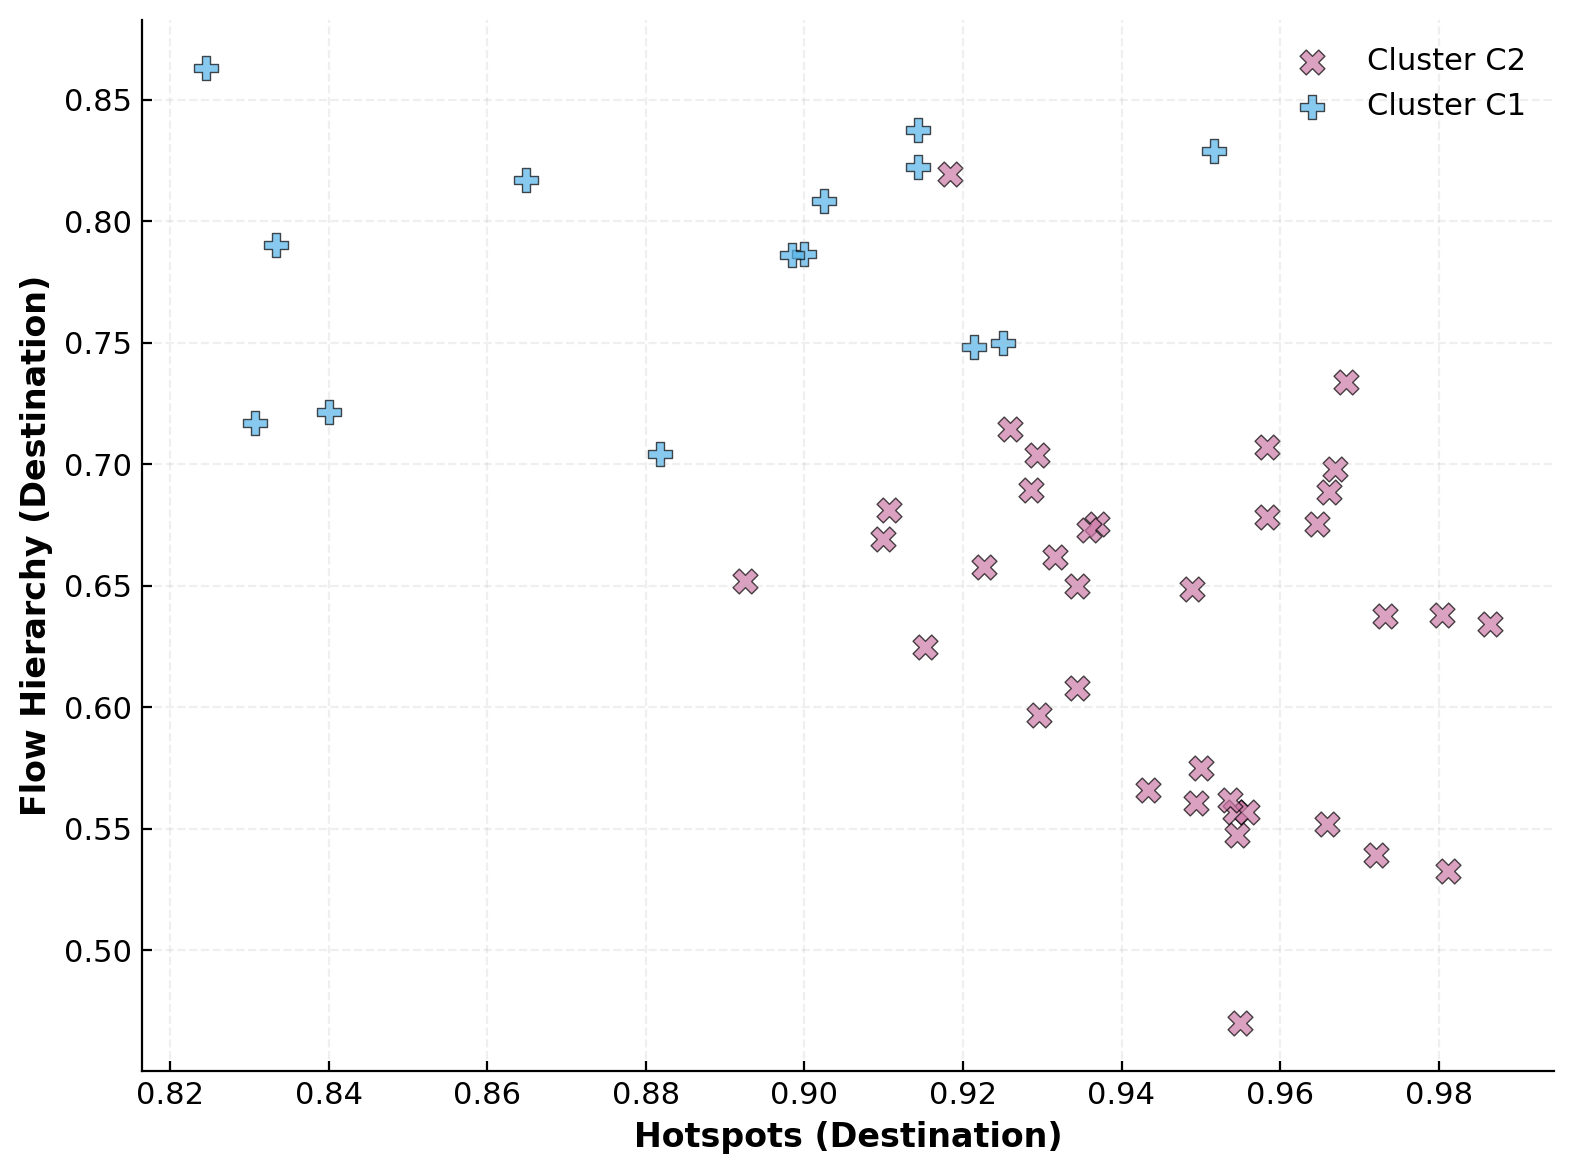

In [9]:
# Create alternative visualization comparing different metrics
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

# Plot each cluster
for marker in data_filtered['marker'].unique():
    subset = data_filtered[data_filtered['marker'] == marker]
    cluster_color = subset['color'].iloc[0]
    cluster_label = subset['cluster'].iloc[0]
    
    ax.scatter(
        subset['hotspots_cuts_1_dest'],
        subset['flow_hierarchy_dest'],
        color=cluster_color,
        marker=marker,
        label=f'Cluster {cluster_label}',
        s=80,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )

# Format plot
ax.set_xlabel('Hotspots (Destination)', fontsize=12, fontweight='bold')
ax.set_ylabel('Flow Hierarchy (Destination)', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='best', frameon=False)
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
print('✓ Alternative scatter plot created')
plt.show()

### 7.2 Distribution Plots by Cluster

✓ Distribution plots created


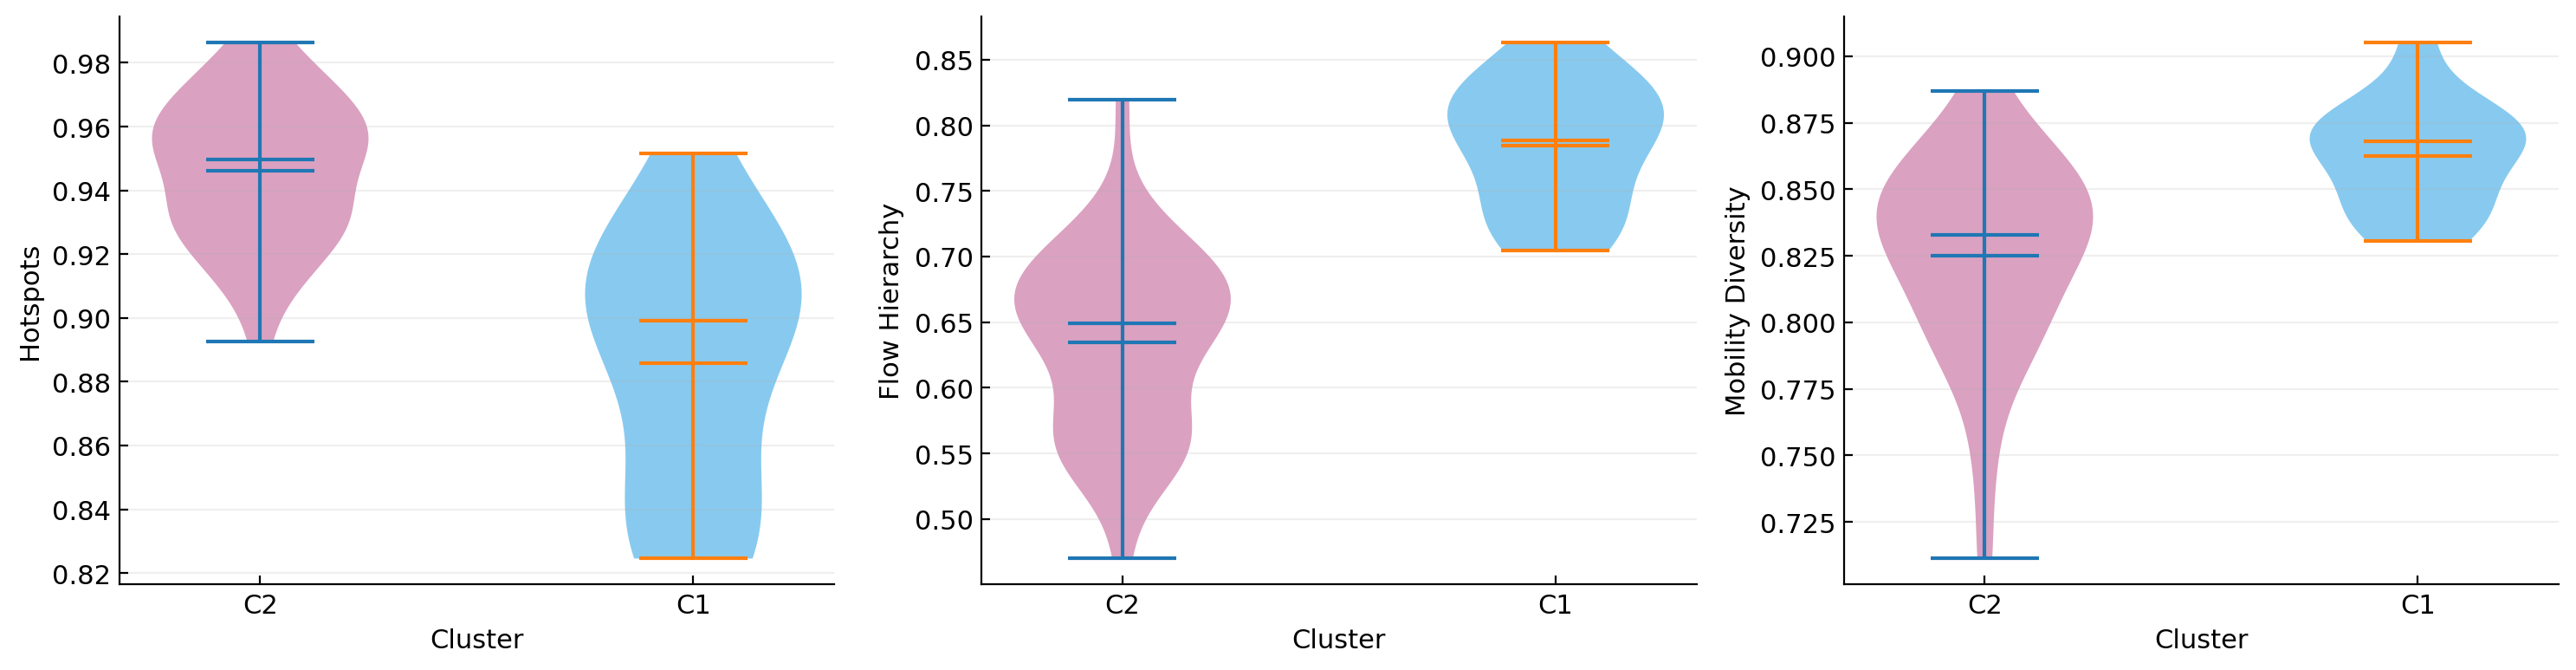

In [10]:
# Create subplots showing distributions of key metrics by cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=200)

metrics = ['hotspots_cuts_1_dest', 'flow_hierarchy_dest', 'mean_mob_div']
labels = ['Hotspots', 'Flow Hierarchy', 'Mobility Diversity']

# Create violin plot for each metric
for ax, metric, label in zip(axes, metrics, labels):
    # Prepare data for violin plot
    clusters = data_filtered['cluster'].unique()
    
    for cluster in clusters:
        subset = data_filtered[data_filtered['cluster'] == cluster]
        cluster_color = colors.get(cluster, 'gray')
        
        # Create violin plot
        parts = ax.violinplot(
            [subset[metric].values],
            positions=[list(clusters).index(cluster)],
            widths=0.5,
            showmeans=True,
            showmedians=True
        )
        
        # Color the violin plot
        for pc in parts['bodies']:
            pc.set_facecolor(cluster_color)
            pc.set_alpha(0.7)
    
    # Format subplot
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_xticks(range(len(clusters)))
    ax.set_xticklabels(clusters)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
print('✓ Distribution plots created')
plt.show()

## 8. Summary Statistics

In [11]:
# Calculate summary statistics by cluster
print(f'\nSummary Statistics for Year {year_of_interest}\n')
print('='*60)

metrics_to_analyze = ['hotspots_cuts_1_dest', 'flow_hierarchy_dest', 'mean_mob_div']

for cluster in sorted(data_filtered['cluster'].unique()):
    subset = data_filtered[data_filtered['cluster'] == cluster]
    print(f'\nCluster {cluster}: {len(subset)} cities')
    print('-'*60)
    
    summary = subset[metrics_to_analyze].describe().T
    print(summary[['mean', 'std', 'min', 'max']].round(3))

print('\n' + '='*60)
print('✓ Summary statistics calculated')


Summary Statistics for Year 2018


Cluster C1: 14 cities
------------------------------------------------------------
                       mean    std    min    max
hotspots_cuts_1_dest  0.886  0.041  0.825  0.952
flow_hierarchy_dest   0.784  0.049  0.704  0.863
mean_mob_div          0.862  0.020  0.831  0.905

Cluster C2: 36 cities
------------------------------------------------------------
                       mean    std    min    max
hotspots_cuts_1_dest  0.946  0.023  0.893  0.986
flow_hierarchy_dest   0.634  0.071  0.470  0.820
mean_mob_div          0.825  0.038  0.711  0.887

✓ Summary statistics calculated


## 9. Export Summary Table

Create a table summarizing key metrics by city and cluster.

In [12]:
# Create summary table for export
summary_table = data_filtered[['city', 'cluster', 'hotspots_cuts_1_dest', 
                                'flow_hierarchy_dest', 'mean_mob_div']].copy()

# Sort by flow hierarchy for better readability
summary_table = summary_table.sort_values('flow_hierarchy_dest', ascending=False)

# Display top cities
print(f'\nTop 10 cities by Flow Hierarchy ({year_of_interest}):\n')
print(summary_table.head(10).to_string(index=False))

# Export to CSV
summary_table.to_csv('city_profiles_summary.csv', index=False)
print(f'\n✓ Summary table exported to: city_profiles_summary.csv')


Top 10 cities by Flow Hierarchy (2018):

          city cluster  hotspots_cuts_1_dest  flow_hierarchy_dest  mean_mob_div
     St. Louis      C1              0.824561             0.863225      0.838128
       Oakland      C1              0.914286             0.837561      0.872298
    Long Beach      C1              0.951613             0.828814      0.870417
Corpus Christi      C1              0.914286             0.822232      0.880526
        Newark      C2              0.918367             0.819690      0.787136
      Chandler      C1              0.864865             0.816925      0.830509
         Miami      C1              0.902439             0.808373      0.857095
Virginia Beach      C1              0.833333             0.790384      0.837450
     Riverside      C1              0.900000             0.786741      0.870530
      San Jose      C1              0.898438             0.786063      0.851820

✓ Summary table exported to: city_profiles_summary.csv
